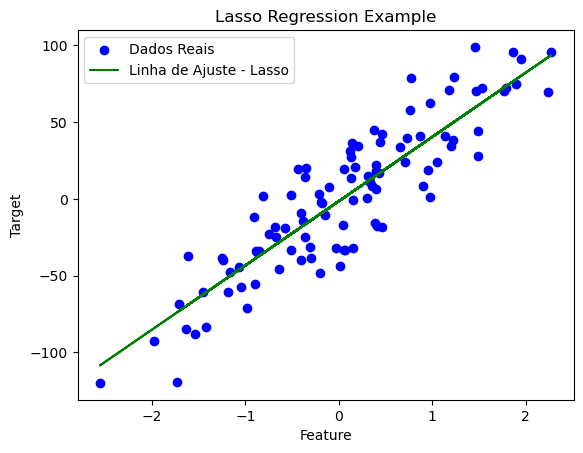

Intercepto: -1.5694874497927493, Coeficiente: 41.86893576677269


In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados
dados = pd.read_csv(resolve_data_path("6.0 - dados_lasso_regression.csv"))

# Preparar os dados
X = dados[['Feature']].values
y = dados['Target'].values

# Criar e treinar o modelo Lasso Regression
modelo_lasso = Lasso(alpha=1.0)  # alpha e o parametro de regularizacao L1
modelo_lasso.fit(X, y)

# Coeficientes do modelo
intercepto_lasso = modelo_lasso.intercept_
coeficiente_lasso = modelo_lasso.coef_[0]

# Previsoes
y_pred_lasso = modelo_lasso.predict(X)

# Visualizar os dados e a linha de ajuste
plt.scatter(X, y, color='blue', label='Dados Reais')
plt.plot(X, y_pred_lasso, color='green', label='Linha de Ajuste - Lasso')
plt.title('Lasso Regression Example')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

print(f'Intercepto: {intercepto_lasso}, Coeficiente: {coeficiente_lasso}')